#  03. Classical Remote Sensing Baselines (NDWI & MNDWI)

Before training deep neural networks, we establish classical baselines using physics-based spectral band math:
1. **NDWI** (McFeeters, 1996): `(Green - NIR) / (Green + NIR)`
2. **MNDWI** (Xu, 2006): `(Green - SWIR1) / (Green + SWIR1)`

**Threshold Optimization Rule**: We search for the optimal detection threshold on the **Validation set only**, and then evaluate once on the unseen **Test set**.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

for candidate in [Path.cwd(), Path.cwd().parent, Path('e:/Cellula_Technologies/Project2/water_segmentation')]:
    if (candidate / 'data' / 'raw' / 'images').exists() and (candidate / 'src').exists():
        project_root = candidate
        break
    elif (candidate / 'water_segmentation' / 'data' / 'raw' / 'images').exists():
        project_root = candidate / 'water_segmentation'
        break
else:
    project_root = Path('e:/Cellula_Technologies/Project2/water_segmentation')

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils.paths import get_data_dirs, resolve_file
from src.models.baseline_indices import search_optimal_threshold, evaluate_index_split


## 1. Run Baseline Evaluations
Searching for optimal threshold on validation set [-0.4, 0.6] with 0.05 step.

In [2]:
img_dir, lbl_dir, splits_dir, stats_dir, checkpoints_dir = get_data_dirs()
val_csv = resolve_file("data/splits/val.csv")
test_csv = resolve_file("data/splits/test.csv")

results = []
for idx_name in ["ndwi", "mndwi"]:
    opt_thresh, val_res = search_optimal_threshold(img_dir, lbl_dir, val_csv, idx_name)
    test_res = evaluate_index_split(img_dir, lbl_dir, test_csv, idx_name, threshold=opt_thresh)
    results.append({
        "Index": idx_name.upper(),
        "Optimal Threshold": opt_thresh,
        "Val IoU": val_res["iou"],
        "Val F1": val_res["f1"],
        "Test IoU": test_res["iou"],
        "Test Precision": test_res["precision"],
        "Test Recall": test_res["recall"],
        "Test F1": test_res["f1"]
    })

df_baseline = pd.DataFrame(results)
display(df_baseline)


,Index,Optimal Threshold,Val IoU,Val F1,Test IoU,Test Precision,Test Recall,Test F1
0,NDWI,-0.30,0.566076,0.722923,0.672515,0.841563,0.770006,0.804196
1,MNDWI,-0.25,0.565585,0.722522,0.696313,0.925798,0.737470,0.820972


## 2. Threshold Sensitivity Curve on Validation Split
Analyzing how IoU, Precision, and Recall change across thresholds.

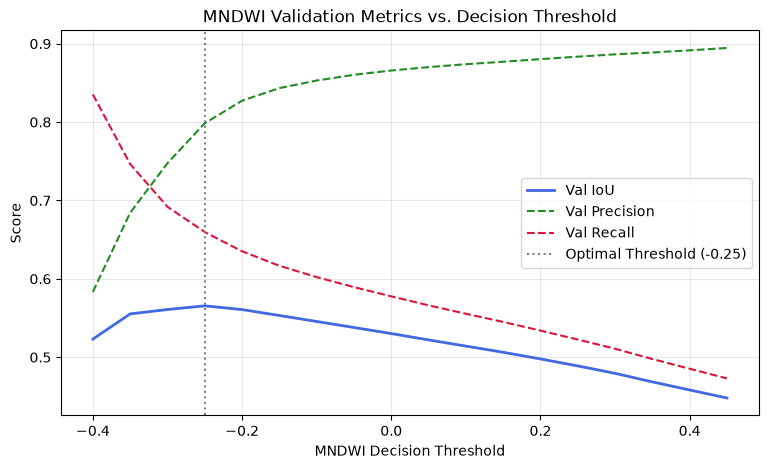

In [3]:
thresholds = np.arange(-0.4, 0.5, 0.05)
ious, precs, recs = [], [], []

for t in thresholds:
    m = evaluate_index_split(img_dir, lbl_dir, val_csv, "mndwi", threshold=t)
    ious.append(m["iou"])
    precs.append(m["precision"])
    recs.append(m["recall"])

plt.figure(figsize=(9, 5))
plt.plot(thresholds, ious, label="Val IoU", color="royalblue", lw=2)
plt.plot(thresholds, precs, label="Val Precision", color="forestgreen", linestyle="--")
plt.plot(thresholds, recs, label="Val Recall", color="crimson", linestyle="--")
plt.axvline(x=-0.25, color="gray", linestyle=":", label="Optimal Threshold (-0.25)")
plt.title("MNDWI Validation Metrics vs. Decision Threshold")
plt.xlabel("MNDWI Decision Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()